TEST

# Zadanie 1


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji parametrycznych, czy jak to się zwie
x, y, t = sp.symbols('x y t')

x = (2 + sp.cos(t)) * sp.cos(t)
y = 2 * (2 + sp.cos(t)) * sp.sin(t)

t_start, t_end = 0, sp.pi / 2

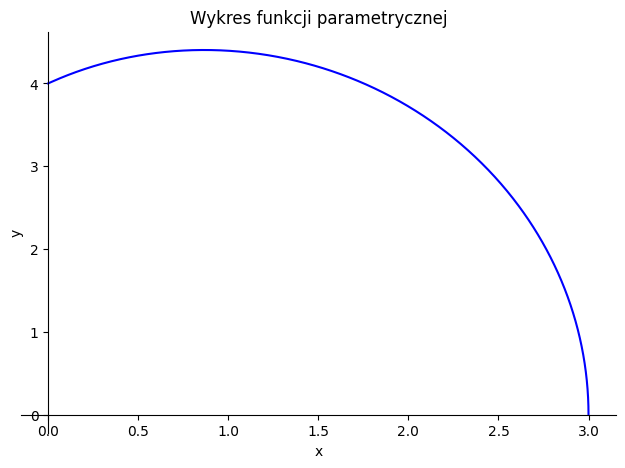

In [2]:
# wykresik
p = sp.plot_parametric(
    (x, y, (t, 0, sp.pi / 2)), 
    title="Wykres funkcji parametrycznej",
    xlabel="x",
    ylabel="y",
    line_color='blue',
    show=True
)

In [3]:
# Obliczanie pierwszych pochodnych po t
dx_dt = sp.diff(x, t)
dy_dt = sp.diff(y, t)

#kolejne pochodne po x
dy_dx = sp.simplify(dy_dt / dx_dt)
d2y_dx2 = sp.simplify(sp.diff(dy_dx, t) / dx_dt)
d3y_dx3 = sp.simplify(sp.diff(d2y_dx2, t) / dx_dt)

# wartosci dla danych pochodnych, dla jakich liczymy je
punkty_d1 = [sp.pi/3, sp.pi/6]
punkty_d2 =[sp.pi/4, sp.pi/9]
punkty_d3 =[sp.pi/12, sp.pi/2]

print("Pochodne: ")
for pt in punkty_d1:
    print(f"dy/dx({pt}) = {dy_dx.subs(t, pt).evalf():.4f}")
for pt in punkty_d2:
    print(f"d^2y/dx^2({pt}) = {d2y_dx2.subs(t, pt).evalf():.4f}")
for pt in punkty_d3:
    print(f"d^3y/dx^3({pt}) = {d3y_dx3.subs(t, pt).evalf():.4f}")

Pochodne: 
dy/dx(pi/3) = -0.3849
dy/dx(pi/6) = -2.3923
d^2y/dx^2(pi/4) = -1.4558
d^2y/dx^2(pi/9) = -9.9648
d^3y/dx^3(pi/12) = -240.4962
d^3y/dx^3(pi/2) = 1.5000


## zadanie 2

In [4]:
t0 = sp.pi / 2
x0 = x.subs(t, t0) 
y0 = y.subs(t, t0) 
m_styczna = dy_dx.subs(t, t0)

x_sym = sp.Symbol('x')
# y - y0 = m * (x - x0) => y = m * (x - x0) + y0, z wzorku na prostą styczną
styczna = m_styczna * (x_sym - x0) + y0

print(f"Punkt styczności (x0, y0): ({x0}, {y0})")
print(f"Nachylenie: {m_styczna}")
print(f"Równanie stycznej: y = {styczna}") 

Punkt styczności (x0, y0): (0, 4)
Nachylenie: 1
Równanie stycznej: y = x + 4


## Zadanie 3

In [5]:
wzor_na_pole = y * (dx_dt)
D_pole = sp.integrate(wzor_na_pole, (t, t_start, t_end))

print(f"Pole obszaru ograniczonego krzywą: {sp.Abs(D_pole.evalf()):.4f}")

Pole obszaru ograniczonego krzywą: 11.0686


## Zadanie 4

In [6]:
luczek = sp.sqrt(dx_dt**2 + dy_dt**2)
luczek_calka = sp.integrate(luczek, (t, t_start, t_end))
print(f"Długość łuku krzywej: {luczek_calka.evalf():.4f}")

Długość łuku krzywej: 6.2677


## Zadanie 5

In [7]:
# objetosc bryly obrotowej

volume = sp.pi * (y**2) * (dx_dt)
volume_calka = sp.integrate(volume, (t, t_start, t_end))

print(f"Objętość bryły obrotowej: {sp.Abs(volume_calka.evalf()):.4f}")

Objętość bryły obrotowej: 136.1357


## Zadanie 6

In [10]:
luczek = sp.sqrt(dx_dt**2 + dy_dt**2)
pole_pole_lyse_pole = 2 * sp.pi * y * luczek
pole_pole_lyse_pole_calka = sp.Integral(pole_pole_lyse_pole, (t, t_start, t_end))
pole_pole_zaokr = pole_pole_lyse_pole_calka.evalf()

print(f"Pole powierzchni bryły obrotowej: {sp.Abs(pole_pole_zaokr):.4f}")

Pole powierzchni bryły obrotowej: 109.1824


# Zadanie 7

In [ ]:
#najpierw masa luku
m_luku = luczek_calka.evalf()

MSx_calka = sp.Integral(y * luczek, (t, t_start, t_end))
MSx_wartosc = MSx_calka.evalf()

#(Ix = całka y^2 ds)
Ix_calka = sp.Integral((y**2) * luczek, (t, t_start, t_end))
Ix_val = Ix_calka.evalf()

print(f"masa luku = {m_luku:.4f}")
print(f"MSx = {MSx_wartosc:.4f}")
print(f"Ix = {Ix_val:.4f}")

masa luku = 6.2677
MSx = 17.3769
Ix = 60.5118


# Zadanie 8

In [13]:
# mega podobne do górnego xD
m_luku = luczek_calka.evalf()

MSy_calka = sp.Integral(x * luczek, (t, t_start, t_end))
MSy_wartosc = MSy_calka.evalf()

Iy_calka = sp.Integral((x**2) * luczek, (t, t_start, t_end))
Iy_wartosc = Iy_calka.evalf()

print(f"masa luku = {m_luku:.4f}")
print(f"MSy = {MSy_wartosc:.4f}")
print(f"Iy = {Iy_wartosc:.4f}")

masa luku = 6.2677
MSy = 12.9602
Iy = 32.0252


## Zadanie 9

In [14]:
xc = MSy_wartosc / m_luku
yc = MSx_wartosc / m_luku

print(f"xc = {round(xc, 4)}, yc = {round(yc, 4)}")

xc = 2.0678, yc = 2.7724


## Zadanie 10

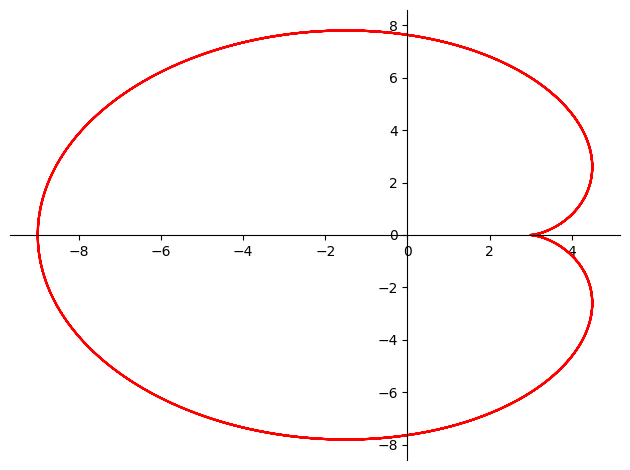

In [16]:
# kardioida - kod podany zostal na wykładzie, pozmienialiśmy parametry
sp.plot_parametric(3*(2*sp.cos(t)-sp.cos(2*t)), 3*(2*sp.sin(t)-sp.sin(2*t)), (t, -15, 15), line_color='red')

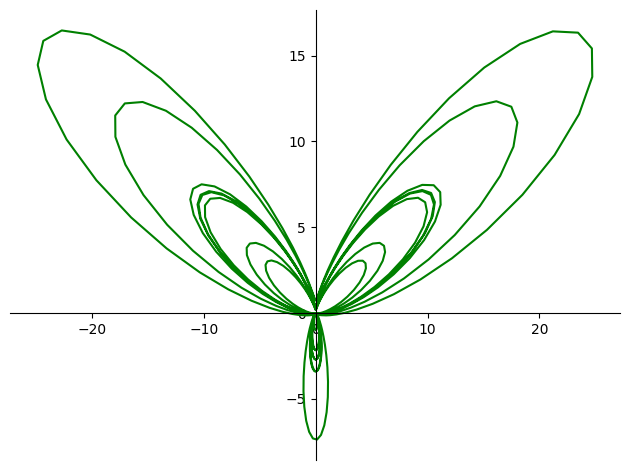

In [ ]:
# Krzywa motylkowa, kod też z wykładu, ale ładniejszy kolor, zielony jest brzydki
# Wyszła w sumie koniczyna 3 listna piekna zieloniutka
sp.plot_parametric(sp.sin(t)*(sp.exp(sp.cos(t)-2*sp.cos(3*t)-(sp.sin(t/(10)))**7)),
sp.cos(t)*(sp.exp(sp.cos(t)-2*sp.cos(3*t)-(sp.sin(t/(10)))**7)),
 (t, -8*sp.pi, 8*sp.pi),line_color='green')